# Additional testing cases: two drawings on one page 


## Set autoreload, library importing, logging, and environment 

In [1]:
# Enable autoreload to automatically pick up changes in local modules
%load_ext autoreload
%autoreload 2

In [2]:
# Import libraries
import logging
from pathlib import Path
from IPython.display import display, Markdown, Image

from docling.document_converter import DocumentConverter, PdfFormatOption
from docling.datamodel.pipeline_options import PdfPipelineOptions
from docling.datamodel.base_models import InputFormat

from doc_agent.utils.logger import setup_logger
from doc_agent.data.docling_parser import parse_document
from utils.extract_page import extract_page_image
from utils.encode_image import encode_image_to_base64


# Configure logging
# Local notebook logger
logger = setup_logger(
    name="004_additional_testing_cases_5", 
    level=logging.INFO,
    log_file="notebook_experiments.log",
    log_dir=Path.cwd() / "logs"
)

logger.info("Logging system successfully initialized.")

2026-05-06 18:34:41 |     INFO | 004_additional_testing_cases_5:2892506005.py:25 - Logging system successfully initialized.


## Workspace & Path Configuration
Setting up relative paths for raw documents, interim data (extracted images and Markdown), and processed outputs.

In [3]:
# Paths relative to the notebook's location (notebooks/data/...)
notebook_root = Path.cwd()
# Path to the pdf-file
pdf_file = notebook_root / "data" / "01_raw" / "one_page_2_drawings.pdf"
logger.info(f"Path to the pdf-file: {pdf_file}")
# Path to the raw md-file
raw_markdown_file = notebook_root / "data" / "02_interim" / "one_page_2_drawings.md"
logger.info(f"Path to the md-file: {raw_markdown_file}")
# Path to the extracted page images
page_images_dir = notebook_root / "data" / "02_interim" / "page_images" 
logger.info(f"Path to the page images directory: {page_images_dir}")

docling_images_dir = notebook_root / "data" / "02_interim" / "docling_images"
logger.info(f"Path to the docling images directory: {docling_images_dir}")


2026-05-06 18:34:42 |     INFO | 004_additional_testing_cases_5:2894652261.py:5 - Path to the pdf-file: /Volumes/SSD/AI/doc_agent/notebooks/data/01_raw/one_page_2_drawings.pdf
2026-05-06 18:34:42 |     INFO | 004_additional_testing_cases_5:2894652261.py:8 - Path to the md-file: /Volumes/SSD/AI/doc_agent/notebooks/data/02_interim/one_page_2_drawings.md
2026-05-06 18:34:42 |     INFO | 004_additional_testing_cases_5:2894652261.py:11 - Path to the page images directory: /Volumes/SSD/AI/doc_agent/notebooks/data/02_interim/page_images
2026-05-06 18:34:42 |     INFO | 004_additional_testing_cases_5:2894652261.py:14 - Path to the docling images directory: /Volumes/SSD/AI/doc_agent/notebooks/data/02_interim/docling_images


In [4]:
logger.info("Starting document parsing process to extract AST...")

# 1. Configure parser options 
pipeline_options = PdfPipelineOptions()
pipeline_options.do_formula_enrichment = True
pipeline_options.generate_picture_images = True
pipeline_options.do_ocr = False # Disable aggressive OCR for schematics

converter = DocumentConverter(
    format_options={
        InputFormat.PDF: PdfFormatOption(pipeline_options=pipeline_options)
    }
)

# 2. Parse the document and retrieve the raw AST (graph)
result = converter.convert(pdf_file)
doc = result.document

logger.info("AST extraction completed")

# 3. Export the raw md-file
raw_markdown_content = doc.export_to_markdown()
raw_markdown_file.write_text(raw_markdown_content, encoding="utf-8")
logger.info(f"Raw markdown successfully saved to {raw_markdown_file.name}")

2026-05-06 18:34:42 |     INFO | 004_additional_testing_cases_5:1272657087.py:1 - Starting document parsing process to extract AST...
2026-05-06 18:35:01 |     INFO | 004_additional_testing_cases_5:1272657087.py:19 - AST extraction completed
2026-05-06 18:35:01 |     INFO | 004_additional_testing_cases_5:1272657087.py:24 - Raw markdown successfully saved to one_page_2_drawings.md


## Create JSON dump from docling structure

In [5]:
import json

with open(notebook_root / "data" / "02_interim" / "ast_dump.json", "w", encoding="utf-8") as f:
    json.dump(doc.export_to_dict(), f, indent=2, ensure_ascii=False)
    
logger.info("JSON dump created.")

2026-05-06 18:35:01 |     INFO | 004_additional_testing_cases_5:3465166242.py:6 - JSON dump created.


## Semantic XML Tagging Execution
Now we apply the `generate_tagged_markdown` function to our parsed `docling` object. 
This step iterates through the document's AST and wraps each semantic block in unique XML-like tags (e.g., `<text_1>...</text_1>`). As a result, we obtain a rigid markup ("factura") that creates ironclad attention boundaries, preventing the VLM from losing context or shuffling paragraphs during the healing phase.

In [6]:
from utils.genetate_tagged_markdown import generate_tagged_markdown

logger.info("Executing XML tagging process...")

# Define the output path for the tagged Markdown file
tagged_md_file = notebook_root / "data" / "02_interim" / f"{pdf_file.stem}_tagged.md"

# Generate the tagged content and persist it to disk
tagged_content = generate_tagged_markdown(
    doc=doc, 
    output_path=tagged_md_file
)

logger.info(f"Tagged markdown successfully generated and saved to {tagged_md_file.name}")
logger.info(f"Total length of tagged content: {len(tagged_content)} characters")

# Render a preview of the resulting tagged text (first 1000 characters)
logger.info("Rendering preview of the tagged markdown:")
print(tagged_content[:1000] + "\n\n... (text truncated for preview)")

2026-05-06 18:35:01 |     INFO | 004_additional_testing_cases_5:446513549.py:3 - Executing XML tagging process...
2026-05-06 18:35:01 |     INFO | 004_additional_testing_cases_5:446513549.py:14 - Tagged markdown successfully generated and saved to one_page_2_drawings_tagged.md
2026-05-06 18:35:01 |     INFO | 004_additional_testing_cases_5:446513549.py:15 - Total length of tagged content: 300 characters
2026-05-06 18:35:01 |     INFO | 004_additional_testing_cases_5:446513549.py:18 - Rendering preview of the tagged markdown:
<text_1>
1 -заземлитель нейтрали источника переменного тока ; 1-1 -заземлитель вывода источника постоянного тока ; 1-2 -заземли -тель средней точки источника постоянного тока ; 2 -открытые проводящие части ; 3 -заземлитель открытых проводящих частей электроустановки ; 4 -источник питания
</text_1>



... (text truncated for preview)


## Extract the target page as a PNG image using PyPDFium2

2026-05-06 18:35:01 |     INFO | 004_additional_testing_cases_5:677466353.py:1 - Starting image extraction  from one_page_2_drawings.pdf...
2026-05-06 18:35:01 |     INFO | 004_additional_testing_cases_5:677466353.py:9 - Image extraction complete. Rendering preview...


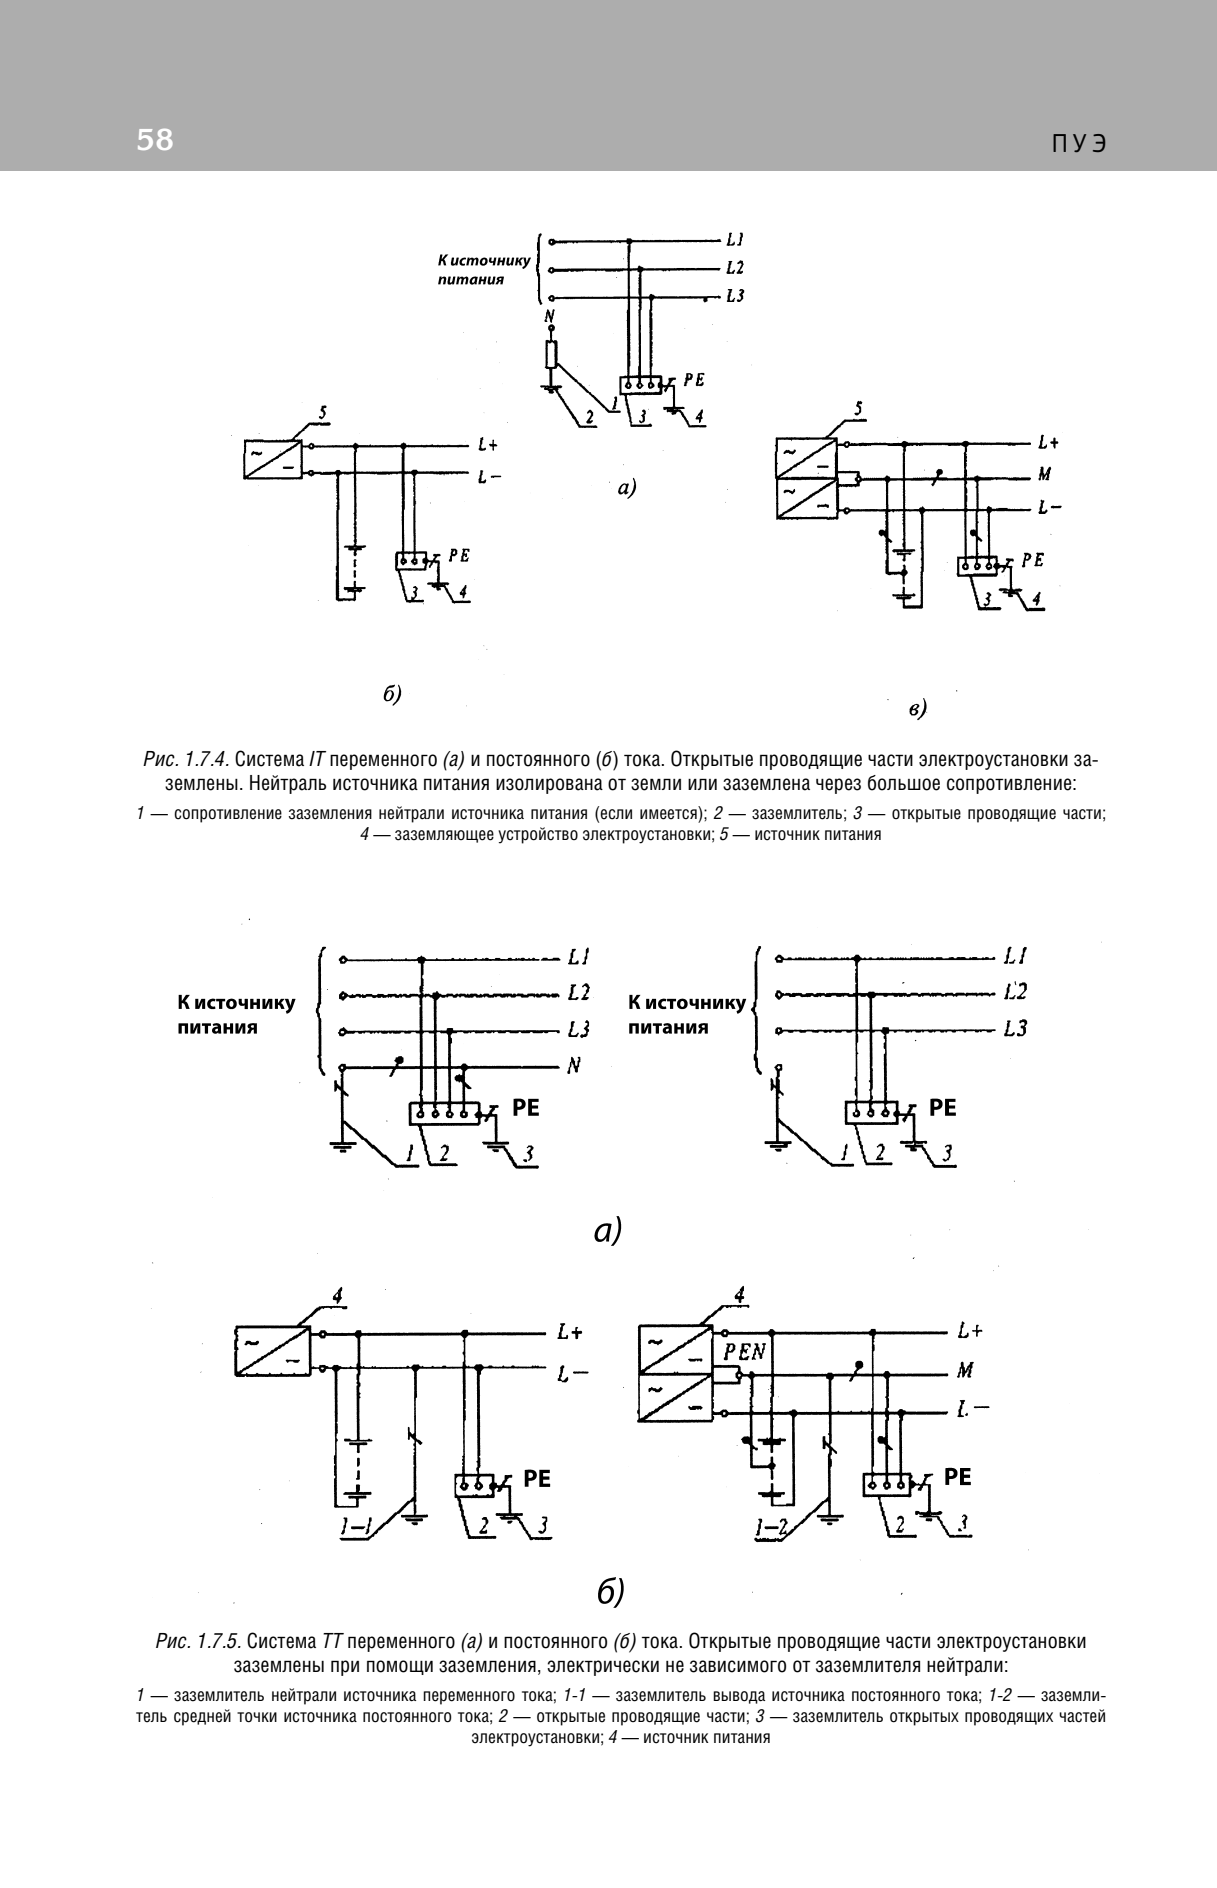

In [7]:
logger.info(f"Starting image extraction  from {pdf_file.name}...")

# Extract the target page as a PNG image
target_image = extract_page_image(
    pdf_path=pdf_file, 
    output_dir=page_images_dir
)

logger.info("Image extraction complete. Rendering preview...")

# Display the extracted image inline
display(Image(filename=target_image, width=800))

## Preparing Inputs for the Vision-Language Model (VLM)
Loading the saved Markdown into memory and converting the target image into a base64 string required by the OpenAI API spec.

In [8]:
# Load raw text
raw_markdown = raw_markdown_file.read_text(encoding="utf-8")
logger.info(f"Loaded raw Markdown: {len(raw_markdown)} characters.")

# Convert image to Base64
base64_image = encode_image_to_base64(target_image)
logger.info("Page image successfully encoded to Base64.")

2026-05-06 18:35:01 |     INFO | 004_additional_testing_cases_5:2864798789.py:3 - Loaded raw Markdown: 295 characters.
2026-05-06 18:35:01 |     INFO | 004_additional_testing_cases_5:2864798789.py:7 - Page image successfully encoded to Base64.


## Agent Inference with Tagged Source Data
Now that we have the tagged text (Tagged MD), we send it to the VLM. We use a Native CoT approach (without rigid JSON-CoT) because the tags already provide the model with an excellent structure for maintaining focus.

In [33]:
import os
from openai import OpenAI
from pydantic import BaseModel, Field
from typing import List

# Setup API Client (assuming dotenv is loaded at the top of notebook)
client = OpenAI(
    api_key=os.environ.get("NANOGPT_API_KEY"),
    base_url=os.environ.get("NANOGPT_BASE_URL") 
)

TARGET_MODEL = "openai/gpt-5-mini" # The main model
# TARGET_MODEL = "google/gemini-flash-latest"
# TARGET_MODEL = "google/gemini-flash-lite-latest"
# TARGET_MODEL = "openai/gpt-5.4-nano"
# TARGET_MODEL = "Qwen/Qwen3.6-35B-A3B"
# TARGET_MODEL = "moonshotai/kimi-k2.6:thinking"
# TARGET_MODEL = "gemini-2.5-flash-preview-09-2025"
# TARGET_MODEL = "openai/gpt-5.4-mini"
# Use Native CoT prompt
prompt_file_cot = notebook_root / "prompts" / "semantic_normalization_native_cot_tagged.md"
system_prompt_cot = prompt_file_cot.read_text(encoding="utf-8")

class NormalizationResultLight(BaseModel):
    clean_markdown: str = Field(
        description="Final, structurally corrected Markdown text WITHOUT any XML tags."
    )

logger.info("Pydantic schema and prompts updated for Tagged processing.")

2026-05-06 21:27:01 |     INFO | 004_additional_testing_cases_5:1243371500.py:29 - Pydantic schema and prompts updated for Tagged processing.


In [34]:
from utils.encode_image import encode_image_to_base64
from utils.display_diff import display_diff

# Encode image
target_image = page_images_dir / f"{pdf_file.stem}_highres.png"
base64_image = encode_image_to_base64(target_image)

logger.info(f"Initiating inference with Tagged MD using model: {TARGET_MODEL}")

try:
    messages = [
        {"role": "system", "content": system_prompt_cot},
        {
            "role": "user",
            "content": [
                {
                    "type": "text", 
                    "text": f"Raw Tagged Markdown for processing:\n\n{tagged_content}"
                },
                {
                    "type": "image_url",
                    "image_url": {
                        "url": f"data:image/png;base64,{base64_image}",
                        "detail": "high"
                    }
                }
            ]
        }
    ]

    response = client.chat.completions.parse(
        model=TARGET_MODEL,
        messages=messages,
        temperature=0.0,
        response_format=NormalizationResultLight,
    )

    tagged_normalized_data = response.choices[0].message.parsed
    logger.info("Inference complete. Checking output...")
    
    # Save the result
    processed_dir = notebook_root / "data" / "03_processed"
    final_output_file = processed_dir / f"{pdf_file.stem}_clean_tagged.md"
    final_output_file.write_text(tagged_normalized_data.clean_markdown, encoding="utf-8")
    
    logger.info(f"Saved to: {final_output_file.name}")

    # Visual Diff: Compare the raw md-file (no tags) and the cleaned md-file
    raw_untagged_md = raw_markdown_file.read_text(encoding="utf-8")
    
    display_diff(
        text_before=raw_untagged_md, 
        text_after=tagged_normalized_data.clean_markdown,
        fromfile='Raw_Docling_Untagged',
        tofile='LLM_Healed_via_Tags'
    )

except Exception as e:
    logger.error(f"Inference failed. Error: {e}", exc_info=True)

2026-05-06 21:27:01 |     INFO | 004_additional_testing_cases_5:3722612486.py:8 - Initiating inference with Tagged MD using model: openai/gpt-5-mini
2026-05-06 21:27:39 |     INFO | 004_additional_testing_cases_5:3722612486.py:39 - Inference complete. Checking output...
2026-05-06 21:27:39 |     INFO | 004_additional_testing_cases_5:3722612486.py:46 - Saved to: one_page_2_drawings_clean_tagged.md


```diff
--- Raw_Docling_Untagged
+++ LLM_Healed_via_Tags
@@ -1,3 +1,20 @@
-<!-- image -->
+**==PICTURE_PLACEHOLDER==**
 
-1 -заземлитель нейтрали источника переменного тока ; 1-1 -заземлитель вывода источника постоянного тока ; 1-2 -заземли -тель средней точки источника постоянного тока ; 2 -открытые проводящие части ; 3 -заземлитель открытых проводящих частей электроустановки ; 4 -источник питания
+Рис. 1.7.4. Система IT переменного (а) и постоянного (б) тока. Открытые проводящие части электроустановки заземлены. Нейтраль источника питания изолирована от земли или заземлена через большое сопротивление:
+
+1 — сопротивление заземления нейтрали источника питания (если имеется);
+2 — заземлитель;
+3 — открытые проводящие части;
+4 — заземляющее устройство электроустановки;
+5 — источник питания
+
+**==PICTURE_PLACEHOLDER==**
+
+Рис. 1.7.5. Система ТТ переменного (а) и постоянного (б) тока. Открытые проводящие части электроустановки заземлены при помощи заземления, электрически не зависимого от заземлителя нейтрали:
+
+1 — заземлитель нейтрали источника переменного тока;
+1-1 — заземлитель вывода источника постоянного тока;
+1-2 — заземлитель средней точки источника постоянного тока;
+2 — открытые проводящие части;
+3 — заземлитель открытых проводящих частей электроустановки;
+4 — источник питания
```

# Improve prompt 

We are adding information about several placeholders and captions for images on one page.

<div style="border: 2px solid #5c6bc0; border-radius: 8px; padding: 20px; background-color: rgba(92, 107, 192, 0.05); box-shadow: 0 4px 6px rgba(0,0,0,0.05); width: fit-content;">

<h3 style="margin-top: 0; color: #5c6bc0; border-bottom: 1px solid #5c6bc0; padding-bottom: 8px;">
  📤 Prompt 
</h3>

```xml
<system_role>
Алгоритм семантической нормализации инженерных данных (OCR Healing Engine).

Цель — преобразовать сырой текст, размеченный XML-подобными тегами, в чистый Markdown, используя изображение страницы для валидации структуры и форматирования. 
</system_role>


<structural_mapping>
- Изолированные математические выражения и формулы (дополнительным тригером можут служить теги <formula_> </formula_> в размеченном XML), обернуть в `$$`, преобразовав в Latex.

- Внутристрочные переменные обернуть в `$`, преобразовав в Latex.

- Востановить таблицы, имеющие невидимые границы.

- Разделение сложных таблиц: если одна ячейка визуально охватывает несколько строк в соседних колонках, запрещено сливать их текст. Разбить на отдельные Markdown-строки: значение общей ячейки писать только в первой строке, в последующих оставлять эту ячейку пустой.

- Подписи таблиц: текст типа "Таблица X.X.X" запрещено удалять или превращать в заголовок страницы/колонтитул (даже если первичный парсер разметил его соответствующим тегом). Оставлять его обычным текстом непосредственно перед самой Markdown-таблицей.

- При наличии схемы, чертежа и изображений на странице использовать плейсхолдлер `**==PICTURE_PLACEHOLDER==**` в этом месте. Подписи к изображениями разместить непосредственно под плейсхолдером. 
  
- Учитывать, что изображений на одной странице может быть несколько. Первичный парсер может упускать это из виду. Для каждого из изображений использовать свой плейсхолдлер `**==PICTURE_PLACEHOLDER==**` с однократным использованием подписи к изображениями под соответствующим плейсхолдером. 

- Первичный парсер на странице с изображениями может часть подписи оставлять на вырезанном изображении, а часть преставлять в виде текста. Это приводит к дублированию подписей под плейсхолдлером `**==PICTURE_PLACEHOLDER==**` в одном Markdown-файле. Исключить такое дублирование.

- Выполнить нумерацию пунктов согласно таблице:
    `Раздел X.` => `#`
    `Глава X.X` => `##`
    `X.X.X` => `###`
    `X.`  => `####`
    Обеспечить логичекую последовательность нумерации пунктов.
    Иногда первичный парсер изображения при разметке текста ошибочно ставит теги <list_item_>  </list_item_> вместо <section_header_> </section_header_>, что приводит к неверной интерпретации вложенности пунктов. Учесть и исправить такие ситуации.
</structural_mapping>


<output_format>
Ответ сгенерировать строго в формате валидного JSON:
- "clean_markdown": (строка) Итоговый исправленный Markdown-текст.
</output_format>
```

</div>

<div style="border: 2px solid #388e3c; border-radius: 8px; padding: 20px; background-color: rgba(56, 142, 60, 0.05); box-shadow: 0 4px 6px rgba(0,0,0,0.05); width: fit-content;">

<h3 style="margin-top: 0; color: #388e3c; border-bottom: 1px solid #388e3c; padding-bottom: 8px;">
  📄 Output
</h3>

**==PICTURE_PLACEHOLDER==**

Рис. 1.7.4. Система IT переменного (a) и постоянного (б) тока. Открытые проводящие части электроустановки заземлены. Нейтраль источника питания изолирована от земли или заземлена через большое сопротивление:

1 — сопротивление заземления нейтрали источника питания (если имеется);
2 — заземлитель;
3 — открытые проводящие части;
4 — заземляющее устройство электроустановки;
5 — источник питания

**==PICTURE_PLACEHOLDER==**

Рис. 1.7.5. Система TT переменного (a) и постоянного (б) тока. Открытые проводящие части электроустановки заземлены при помощи заземления, электрически не зависимого от заземлителя нейтрали:

1 — заземлитель нейтрали источника переменного тока;
1-1 — заземлитель вывода источника постоянного тока;
1-2 — заземлитель средней точки источника постоянного тока;
2 — открытые проводящие части;
3 — заземлитель открытых проводящих частей электроустановки;
4 — источник питания

</div>